In [67]:
print("Everything is working fine!")

Everything is working fine!


In [68]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

In [69]:
import warnings
warnings.filterwarnings("ignore")


In [70]:
load_dotenv()

True

In [71]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
OPENWEATHER_API_KEY = os.getenv("OPENWEATHER_API_KEY")
HOTEL_API_KEY = os.getenv("HOTEL_API_KEY")
FLIGHT_API_KEY = os.getenv("FLIGHT_API_KEY")
TRAIN_API_KEY = os.getenv("TRAIN_API_KEY")

In [72]:
from datetime import datetime
from langchain_core.tools import tool
from langchain_tavily import TavilySearch

In [73]:
@tool
def get_datetime():
    """Get Current date and time."""
    current_time = datetime.now()
    return current_time.strftime("%Y-%m-%d %H:%M:%S")

In [74]:
result = get_datetime.invoke({})
print(result)

2026-08-15 13:24:22


In [75]:
import requests

In [76]:
@tool
def get_weather(city: str):
    """Get current weather for the city."""
    api_key = os.getenv("OPENWEATHER_API_KEY")
    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {
        "q": city,
        "appid": api_key,
        "units": "metric"
    }
    response = requests.get(url, params= params)

    if response.status_code != 200:
        return f"Error: Unable to fetch weather data for {city}. Status code: {response.status_code}"
    data = response.json()

    location = data["name"]
    country = data["sys"]["country"]
    temperature = data["main"]["temp"]
    feels_like = data["main"]["feels_like"]
    humidity = data["main"]["humidity"]
    condition = data["weather"][0]["description"]
    wind_speed = data["wind"]["speed"]

    return (
        f"Weather in {location}, {country}: "
        f"{temperature}°C, feels like {feels_like}°C, "
        f"{condition}, humidity {humidity}%, "
        f"wind speed {wind_speed} m/s"
    )


In [77]:
# weather = get_weather.invoke({"city": "Goa"})
# print(weather)

In [78]:
@tool
def get_hotels(city: str,check_in_date: str,check_out_date: str,adults: int):
    """Get hotel information for the given city and dates using SerpApi."""

    api_key = os.getenv("HOTEL_API_KEY")

    if not api_key:
        return "Error: HOTEL_API_KEY is not configured."

    url = "https://serpapi.com/search.json"

    params = {
        "engine": "google_hotels",
        "q": f"{city} hotels",
        "check_in_date": check_in_date,
        "check_out_date": check_out_date,
        "adults": adults,
        "currency": "INR",
        "api_key": api_key
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        return (
            f"Error: Unable to fetch hotel data for {city}. "
            f"Status code: {response.status_code}. "
            f"Response: {response.text[:500]}"
        )

    data = response.json()

    if "error" in data:
        return f"SerpApi error: {data['error']}"

    hotels = data.get("properties", [])

    if not hotels:
        return f"No hotels found in {city} for the selected dates."

    results = []

    for hotel in hotels[:5]:
        rate = hotel.get("rate_per_night") or {}
        total = hotel.get("total_rate") or {}

        results.append({
        "name": hotel.get("name"),
        "rating": hotel.get("overall_rating"),

        "price_per_night": rate.get("extracted_lowest"),
        "total_price": total.get("extracted_lowest"),
        "price_before_taxes": total.get("extracted_before_taxes_fees"),

        "check_in_time": hotel.get("check_in_time"),
        "check_out_time": hotel.get("check_out_time"),

        "location": hotel.get("gps_coordinates"),
        "link": hotel.get("link"),
        "nearby_places": hotel.get("nearby_places", [])
    })

    return results

In [79]:
# result = get_hotels.invoke({
#     "city": "Goa",
#     "check_in_date": "2026-08-20",
#     "check_out_date": "2026-08-23",
#     "adults": 2
# })

# print("HOTEL DATA:")
# print(result)

In [80]:
@tool
def get_flights(departure_id: str,arrival_id: str,outbound_date: str,return_date: str):
    """Get flight information between two airports for the given dates."""

    api_key = os.getenv("FLIGHT_API_KEY")

    url = "https://serpapi.com/search.json"

    params = {
        "engine": "google_flights",
        "departure_id": departure_id,
        "arrival_id": arrival_id,
        "outbound_date": outbound_date,
        "return_date": return_date,
        "type": "1",              
        "travel_class": "1",    
        "currency": "INR",
        "stops": "0",            
        "api_key": api_key
    }

    try:
        response = requests.get(
            url,
            params=params,
            timeout=30
        )

        if response.status_code != 200:
            return (
                f"Error: Unable to fetch flight data. "
                f"Status code: {response.status_code}. "
                f"Response: {response.text}"
            )

        data = response.json()

        if "error" in data:
            return f"SerpAPI error: {data['error']}"

        best_flights = data.get("best_flights", [])

        if not best_flights:
            return (
                f"No flights found from {departure_id} "
                f"to {arrival_id} for {outbound_date}."
            )

        results = []

        all_flights = data.get("best_flights", []) + data.get("other_flights", [])

        for option in all_flights[:5]:
            segments = option.get("flights", [])
            if not segments:
                continue

            first_segment = segments[0]
            last_segment = segments[-1]
            departure = first_segment.get("departure_airport", {})
            arrival = last_segment.get("arrival_airport", {})

            results.append({
                "airline": first_segment.get("airline"),
                "flight_number": first_segment.get("flight_number"),

                "departure_airport": departure.get("name"),
                "departure_code": departure.get("id"),
                "departure_time": departure.get("time"),

                "arrival_airport": arrival.get("name"),
                "arrival_code": arrival.get("id"),
                "arrival_time": arrival.get("time"),

                "duration_minutes": option.get("total_duration"),
                "price_inr": option.get("price"),
                "stops": len(segments) - 1,
                "booking_url": data.get("search_metadata", {}).get("google_flights_url")
            })

        return results

    except requests.RequestException as e:
        return f"Flight API request failed: {str(e)}"

In [81]:
# result = get_flights.invoke({
#      "departure_id": "DEL",
#      "arrival_id": "GOI",
#      "outbound_date": "2026-08-20",
#      "return_date": "2026-08-23"
#  })

# print(result)

In [82]:
@tool
def get_trains(departure_station: str, arrival_station: str, travel_date: str):
    """Get trains running between two Indian railway stations on a given date."""

    api_key = os.getenv("TRAIN_API_KEY")

    url = (f"https://api.railradar.in/v1/trains/between/{departure_station}/{arrival_station}")

    params = {
        "date": travel_date,
        "live": "false",
        "byCity": "true"
    }

    headers = {
        "Authorization": f"Bearer {api_key}"
    }

    response = requests.get(url, params=params, headers=headers)

    if response.status_code != 200:
        return f"Error: Unable to fetch train data. Status code: {response.status_code}"

    data = response.json()

    trains = data.get("data", {}).get("trains", [])
    if not trains:
        return "No trains found for this route and date."


    results = []

    for option in trains[:5]:
        train = option.get("train", {})
        from_data = option.get("from", {})
        to_data = option.get("to", {})

        results.append({
            "train_number": train.get("number"),
            "train_name": train.get("name"),
            "train_type": train.get("type"),
            "departure_station": departure_station,
            "departure_time": from_data.get("departure"),
            "arrival_station": arrival_station,
            "arrival_time": to_data.get("arrival"),
            "duration": option.get("duration"),
            "distance": option.get("distance"),
            "halts": option.get("totalHaltsBetween"),
            "booking_url": "https://www.irctc.co.in/nget/train-search"
        })

    return results

In [83]:
# result = get_trains.invoke({
#     "departure_station": "UJN",
#     "arrival_station": "INDB",
#     "travel_date": "2026-08-20"
# })

# print(result)

In [84]:
@tool
def get_buses(departure_city: str, arrival_city: str, travel_date: str):
    """
    Find bus options including operator name, departure/arrival time,
    price and booking URL.
    """

    query = f"""
    Find bus tickets from {departure_city} to {arrival_city}
    for {travel_date}.

    Search specifically for actual bus ticket listings.
    I need:
    - bus operator name
    - departure time
    - arrival time
    - duration
    - ticket price in INR
    - booking URL

    Prefer booking websites such as AbhiBus, EaseMyTrip,
    redBus, Paytm Bus, MakeMyTrip or similar.
    Do not return general travel articles.
    """

    tavily_search = TavilySearch(
        api_key=TAVILY_API_KEY,
        max_results=5,
        search_depth="advanced"
    )

    results = tavily_search.invoke(query)

    if not results or not results.get("results"):
        return "No bus information found."

    buses = []

    for result in results["results"]:

        title = result.get("title", "")
        content = result.get("content", "")
        url = result.get("url", "")

        buses.append({
            "booking_website": title,
            "information": content,
            "url": url
        })

    return {
        "route": f"{departure_city} → {arrival_city}",
        "travel_date": travel_date,
        "buses": buses
    }

In [85]:
# result = get_buses.invoke({
#         "departure_city": "Delhi",
#         "arrival_city": "Mumbai",
#         "travel_date": "2026-08-20"
#     })
# print(result)

In [86]:
tools = [get_weather, get_flights, get_trains, get_buses, get_hotels]

In [87]:
llm= ChatGroq(model="openai/gpt-oss-120b", temperature=0.4)
llm_with_tools = llm.bind_tools(tools, tool_choice='auto')

In [88]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020967F3D950>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020967F3E350>, model_name='openai/gpt-oss-120b', temperature=0.4, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'get_weather',

In [89]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.graph.message import AnyMessage, add_messages
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import display, Image

In [90]:
class AgentState(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

In [91]:
system_prompt = """
You are an intelligent AI Travel Assistant with more than 15 years of travel-planning experience.

Your job is to help users plan trips using the available tools.

Available information:
- Flights
- Trains
- Buses
- Hotels
- Weather
- Estimated total trip cost

RULES:
1. Use the appropriate tools whenever real-time or external information is required.
2. You may call multiple tools, either sequentially or when appropriate.
3. After receiving all required tool results, DO NOT call another tool unless information is genuinely missing.
4. Give the user ONE final, well-organized answer.
5. NEVER expose tool calls, tool arguments, ToolMessage, Call ID, or internal reasoning.
6. Do not simply repeat raw API responses.
7. Extract and summarize the useful information from tool results.
8. If some information is unavailable, clearly say "Not available" instead of making it up.
9. Always include source/booking URLs when available.

FORMAT THE FINAL ANSWER LIKE THIS:

# ✈️ Trip Plan: Delhi → Goa

**Travel dates:** 20 August 2026 → 23 August 2026

## ✈️ Flights
Show the best available flight options in a small table:

| Airline | Departure | Arrival | Price | Source |

## 🚆 Trains
Show the best available train options:

| Train | Departure | Arrival | Duration | Price/Info | Source |

If train information is unavailable, say so clearly.

## 🚌 Buses

Show 2–3 available bus options for the requested route and travel date.

Include the following information whenever available:

| Bus Operator | Departure | Arrival | Duration | Price (₹) | Booking Website | Source |

Rules:
- Show the actual bus operator name when available.
- Show departure time, arrival time, duration, and ticket price when available.
- Show the booking website and source URL.
- Do not invent bus prices, timings, operators, or durations.
- If any information is unavailable, write "Not available".
- Treat each bus as an alternative transportation option.
- Do not add multiple bus prices together when calculating the total trip cost.
- Only the selected/recommended bus should be included in the final trip cost.

## 🏨 Hotels
Show the best available hotel options:

| Hotel | Location | Price | Rating | Source |

## 🌦️ Weather
Give a short weather summary for the destination for the requested dates.

## 💰 Estimated Trip Cost

### Selected Options

| Category | Selected Option | Cost |
| ✈️ Transportation | Air India Express | choose min |
| 🏨 Hotel | Moustache Goa Luxuria | choose minimum cost |
| 🍴 Other Expenses | Estimated | choose min cost |
| | **Total** | **price after adding** |

IMPORTANT:

- Never add alternative transportation options.
- Never add alternative hotels.
- Only the selected/recommended options are included in the final total.
- Clearly mention that other expenses are estimates.
- If a price is unavailable, write "Not available".
- Do not invent missing prices.

## 📌 Recommendation
Give a short recommendation for the best overall option based on price, duration, and convenience.

Keep the final response concise, readable, and useful.
"""

In [92]:
def agent_node(state: AgentState):
    state_messages = state["messages"]
    messages = [SystemMessage(content = system_prompt)] + state_messages
    response = llm_with_tools.invoke(messages)
    return {"messages" : [response]}

In [93]:
builder = StateGraph(AgentState)
builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(tools))

In [94]:
builder.add_edge(START,"agent")
builder.add_conditional_edges("agent", tools_condition)
builder.add_edge("tools", "agent")
builder.add_edge("agent", END)

In [95]:
# Memory 
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
graph_memory = builder.compile(checkpointer=memory,name="react_agent_with_memory")

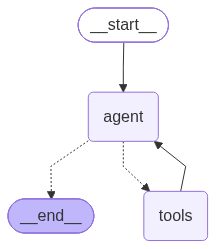

In [96]:
display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [97]:
# Thread
config = {"configurable" :{"thread_id":"1"}}


In [98]:
response = graph_memory.invoke({ "messages": [
        (
            "user",
            """I want to travel from Ujjain to Indore from 20–23 August 2026. Find flights, train, buses, weather."""
        )
    ]
}, config=config)

from IPython.display import Markdown, display
from langchain_core.messages import AIMessage

for msg in reversed(response["messages"]):
    if isinstance(msg, AIMessage) and msg.content and not msg.tool_calls:
        display(Markdown(msg.content))
        break

# ✈️ Trip Plan: Ujjain → Indore  

**Travel dates:** 20 August 2026 → 23 August 2026  

---

## 🚆 Trains  
| Train | Departure | Arrival | Duration | Price/Info | Source |
|-------|-----------|---------|----------|------------|--------|
| 19304 – Bhopal – Indore Express | 03:05 AM (UJN) | 04:45 AM (INDB) | 1 h 40 m | IRCTC booking | https://www.irctc.co.in/nget/train-search |
| 19309 – Indore Junction SHANTI EXPRESS | 03:50 AM (UJN) | 05:45 AM (INDB) | 1 h 55 m | IRCTC booking | https://www.irctc.co.in/nget/train-search |
| 19302 – Dr. Ambedkar Nagar Weekly Express | 04:45 AM (UJN) | 06:10 AM (INDB) | 1 h 25 m | IRCTC booking | https://www.irctc.co.in/nget/train-search |

*All trains run daily; tickets can be booked via the IRCTC portal.*

---

## 🚌 Buses  
| Bus Operator | Departure | Arrival | Duration | Price (₹) | Booking Website | Source |
|--------------|-----------|---------|----------|-----------|-----------------|--------|
| **Zingbus** (Zingbus) | 08:30 AM (Ujjain) | ~10:00 AM (Indore) | 1 h 30 m (approx.) | Not available | https://www.zingbus.com/bus-tickets/ujjain-bus-booking-online | Zingbus |
| **Royal Travels (AICTSL)** | 06:50 AM (Ujjain) | ~09:20 AM (Indore) | 2 h 30 m (approx.) | Not available | https://www.easemytrip.com/bus/ujjain-to-indore-bus-tickets | EaseMyTrip |
| **Various (Royal Travels, Baneshwari Travels, Hans Travels)** – Uber Intercity | Not listed | Not listed | Not listed | From ₹65 (one‑way) – average ₹917 | https://www.uber.com/in/en/r/intercity/ujjain-madhya-pradesh-to-indore-madhya-pradesh/bus | Uber |

*The Uber intercity service gives the lowest guaranteed fare (₹65 one‑way).*

---

## 🏨 Hotels  
| Hotel | Location | Price (₹) | Rating | Source |
|-------|----------|-----------|--------|--------|
| **HRJ Sarovar Portico Hotel** | Central Indore | 10 397 (3 nights) | 4.3 ★ | https://www.sarovarhotels.com/sarovar-portico-indore/ |
| Essentia Luxury Hotel Indore | Central Indore | 13 680 (3 nights) | 4.5 ★ | https://www.essentiahotels.in/luxury-hotel-indore/ |
| Radisson Blu Hotel Indore | Central Indore | 19 019 (3 nights) | 4.5 ★ | https://www.radissonhotels.com/en-us/hotels/radisson-blu-indore?cid=a:se+b:gmb+c:apac+i:local+e:rdb+d:ind+h:INMPIDR2 |

*The cheapest option is highlighted in the cost estimate below.*

---

## 🌦️ Weather (Indore, 20‑23 Aug 2026)  
- **Average temperature:** ~25 °C (77 °F)  
- **Conditions:** Light rain, high humidity (≈ 88 %)  
- **Wind:** Gentle breezes (~5 m s⁻¹)  

Carry a light rain jacket or umbrella.

---

## 💰 Estimated Trip Cost  

### Selected Options  

| Category | Selected Option | Cost |
|----------|----------------|------|
| 🚌 Transportation | Uber intercity (₹65 one‑way × 2) | **₹130** |
| 🏨 Hotel | HRJ Sarovar Portico Hotel (₹10 397 total) | **₹10 397** |
| 🍴 Other Expenses* | Food, local transport, misc. (≈ ₹1 500 / day) | **₹4 500** |
| **Total** |  | **₹15 027** |

\*Other expenses are rough estimates; actual spend may vary.

---

## 📌 Recommendation  
For the best balance of price and convenience, take the **Uber intercity bus** (₹65 each way) and stay at the **HRJ Sarovar Portico Hotel**, the most affordable comfortable hotel in Indore. The bus departs early in the morning, giving you plenty of time to settle in and explore the city. Trains are also available if you prefer rail travel, but the bus‑hotel combo offers the lowest overall cost while keeping travel time under 3 hours each way. Enjoy your trip!